# PlantVillage - Refinamento Focado em Classes Fracas

Este notebook é um laboratório para melhorar classes específicas sem continuar refinando o modelo inteiro no escuro. A meta é investigar erros, comparar estratégias leves e decidir se vale usar `class_weight`, oversampling ou um modelo especializado por cultura.

Classes-alvo iniciais:

- `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot`
- `Corn_(maize)___Northern_Leaf_Blight`
- `Potato___healthy`


## 1. Imports e Configuração

Mantemos os mesmos imports centrais do projeto e adicionamos utilitários para pesos de classe, matrizes de confusão e análise por classe.


In [10]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


## 2. Parâmetros do Experimento

Comece com parâmetros conservadores. Se sua máquina falhar, reduza `batch_size` para 8 e mantenha o `shuffle_buffer` menor que o total do treino.


In [11]:
DATA_DIR = "plantvillage_dataset/color"
BASE_MODEL_PATH = "models/efficientnet_b0_fine_tuned_best_val_09877.keras"
FALLBACK_MODEL_PATH = "models/efficientnet_b0_fine_tuned_5_epochs.keras"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SHUFFLE_BUFFER = 4096
SEED = 42

TARGET_CLASSES = [
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___healthy",
]


## 3. Carregar Caminhos e Recriar o Mesmo Split

Para comparar corretamente com seus notebooks anteriores, mantenha o mesmo split estratificado com `random_state=42`. Isso evita comparar modelos em conjuntos diferentes.


In [12]:
def load_data(path):
    files = []
    labels = []
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(valid_extensions):
                    files.append(os.path.join(label_path, file))
                    labels.append(label)

    return files, labels

files, labels = load_data(DATA_DIR)

train_files, temp_files, train_labels, temp_labels = train_test_split(
    files,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels,
)

print("Treino:", len(train_files))
print("Validação:", len(val_files))
print("Teste:", len(test_files))
print("Classes:", len(set(labels)))


Treino: 43444
Validação: 5430
Teste: 5431
Classes: 38


## 4. Mapeamento de Classes

O mapeamento precisa ser igual ao usado no treino anterior. Usar `sorted(set(labels))` mantêm a ordem determinística.


In [13]:
class_names = sorted(set(labels))
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
num_classes = len(class_names)

for class_name in TARGET_CLASSES:
    print(class_name, "->", class_to_idx[class_name])


Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> 7
Corn_(maize)___Northern_Leaf_Blight -> 9
Potato___healthy -> 22


## 5. Converter Labels e Criar Pipeline Leve

Este pipeline mantêm a escala `0-255`, adequada para EfficientNetB0 do Keras. O `shuffle_buffer` menor reduz memória em comparação com embaralhar o dataset inteiro.


In [14]:
train_label_ids = [class_to_idx[label] for label in train_labels]
val_label_ids = [class_to_idx[label] for label in val_labels]
test_label_ids = [class_to_idx[label] for label in test_labels]

def load_image(image_path, label_id):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label_id

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_label_ids))
val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_label_ids))
test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_label_ids))

train_ds = (
    train_ds
    .shuffle(buffer_size=SHUFFLE_BUFFER, seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

for images, targets in train_ds.take(1):
    print(images.shape, targets.shape)


(16, 224, 224, 3) (16,)


## 6. Carregar o Melhor Modelo Atual

Tente carregar o modelo salvo como melhor candidato. Se esse arquivo ainda não existir, use o fallback de 5 épocas.


In [15]:
model_path = BASE_MODEL_PATH if Path(BASE_MODEL_PATH).exists() else FALLBACK_MODEL_PATH
print("Carregando:", model_path)

model = tf.keras.models.load_model(model_path)


Carregando: models/efficientnet_b0_fine_tuned_5_epochs.keras


## 7. Avaliação Atual das Classes-Alvo

Antes de treinar qualquer coisa, medioms o estado atual. Isso será noso baseline para saber se o refinamento focado realmente ajudou.


In [16]:
def collect_predictions(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels_batch in dataset:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        y_true.extend(labels_batch.numpy())
        y_pred.extend(pred_classes)
        y_prob.extend(np.max(preds, axis=1))

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true_val, y_pred_val, y_prob_val = collect_predictions(model, val_ds)

print(classification_report(
    y_true_val,
    y_pred_val,
    target_names=class_names,
    digits=4,
))


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9839    0.9683    0.9760        63
                                 Apple___Black_rot     0.9841    1.0000    0.9920        62
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        28
                                   Apple___healthy     0.9878    0.9878    0.9878       164
                               Blueberry___healthy     1.0000    1.0000    1.0000       150
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9905    0.9952       105
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000        86
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9318    0.7885    0.8542        52
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       119
               Corn_(maize)___Northern_Leaf_Blight     0.8972    0.9697    0.93

## 8. Confusões das Classes Fracas

Aqui você identifica para onde as classes-alvo estão sendo desviadas. Essa etapa decide a estratégia: se `Cercospora` vira `Northern Leaf Blight`, talvez o problema seja separação fina dentro de milho; se `Potato healthy` vira doença, talvez falte representação saudável.


In [17]:
for class_name in TARGET_CLASSES:
    class_id = class_to_idx[class_name]
    confused = []

    for true_id, pred_id in zip(y_true_val, y_pred_val):
        if true_id == class_id and pred_id != class_id:
            confused.append(idx_to_class[int(pred_id)])

    print("Classe real:", class_name)
    print("Total de erros:", len(confused))
    print(Counter(confused))


Classe real: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Total de erros: 11
Counter({'Corn_(maize)___Northern_Leaf_Blight': 11})
Classe real: Corn_(maize)___Northern_Leaf_Blight
Total de erros: 3
Counter({'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 3})
Classe real: Potato___healthy
Total de erros: 3
Counter({'Potato___Late_blight': 2, 'Apple___healthy': 1})


## 9. Visualizar Erros de Uma Classe-Alvo

Escolha uma classe e inspecione os erros. O objetivo é descobrir se os erros são aceitáveis, se há rótulos duvidosos ou se a classe é visualmente muito parecida com outra.


Erros encontrados: 11


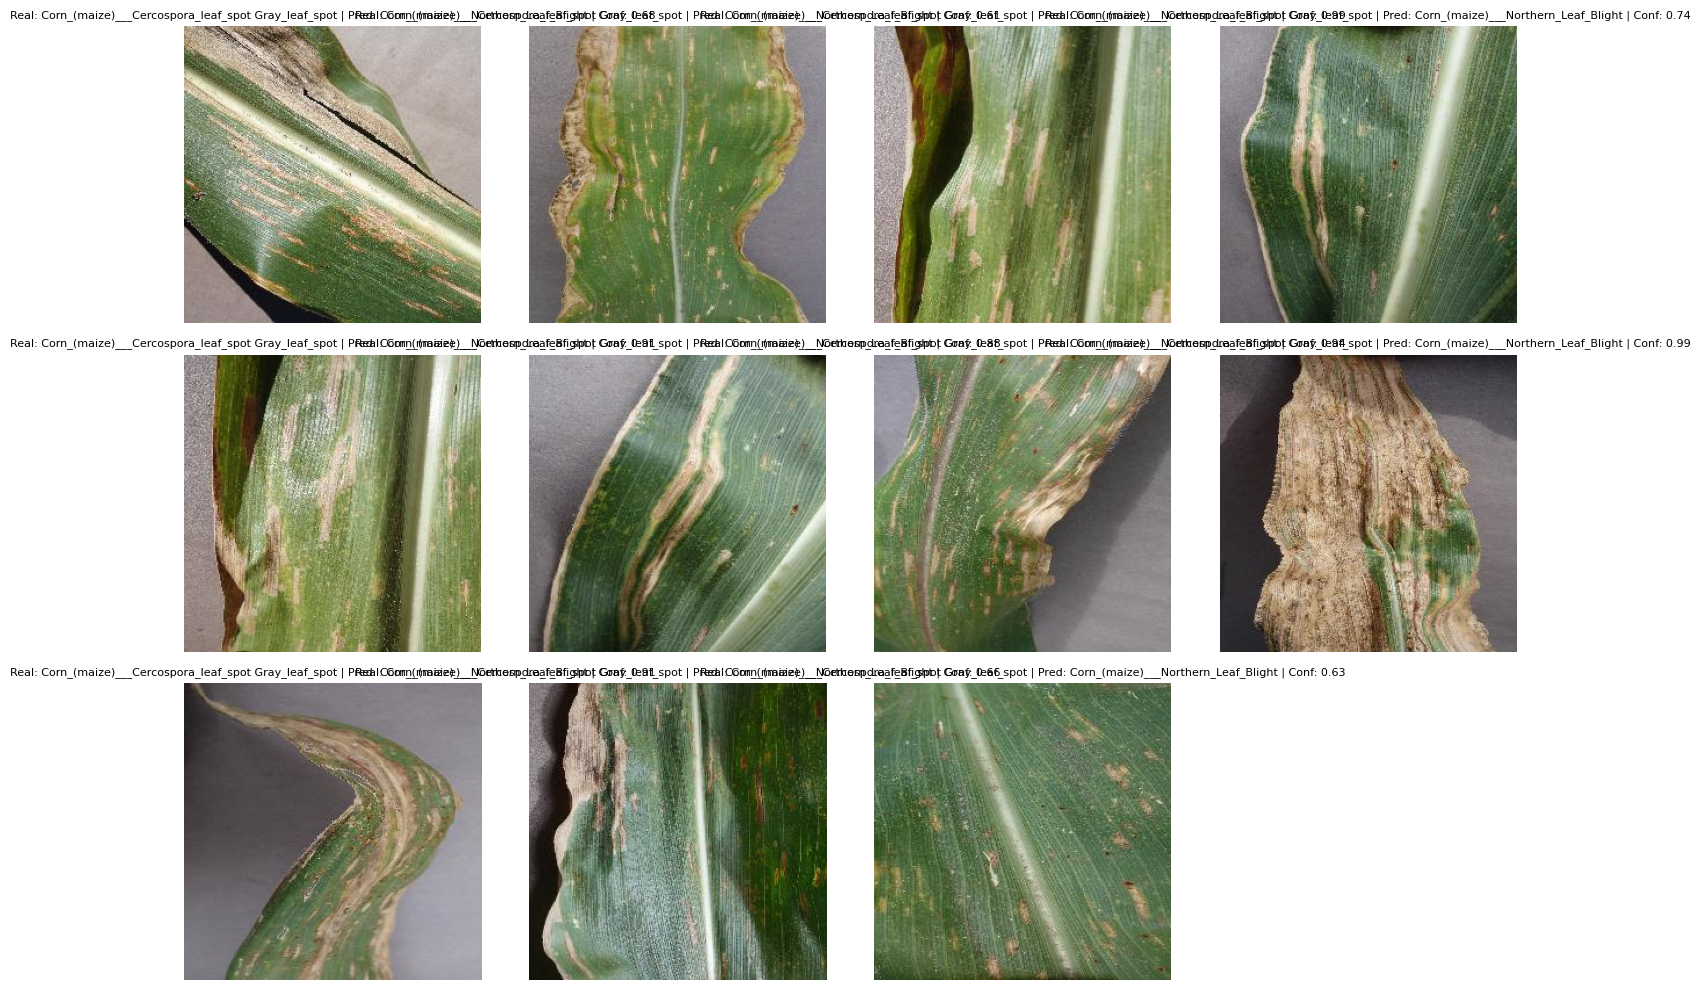

In [18]:
TARGET_TO_INSPECT = "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot"

def make_path_dataset(files_subset, label_ids_subset):
    ds = tf.data.Dataset.from_tensor_slices((files_subset, label_ids_subset))
    ds = ds.map(lambda path, label: (path, *load_image(path, label)), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_path_ds = make_path_dataset(val_files, val_label_ids)

target_id = class_to_idx[TARGET_TO_INSPECT]
class_errors = []

for paths_batch, images, labels_batch in val_path_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    for i in range(len(labels_batch)):
        true_id = int(labels_batch[i])
        pred_id = int(pred_classes[i])

        if true_id == target_id and pred_id != true_id:
            confidence = float(np.max(preds[i]))
            class_errors.append((paths_batch[i].numpy().decode("utf-8"), true_id, pred_id, confidence))

print("Erros encontrados:", len(class_errors))

plt.figure(figsize=(14, 10))
for i, (image_path, true_id, pred_id, conf) in enumerate(class_errors[:12]):
    img = Image.open(image_path).convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {idx_to_class[true_id]} | Pred: {idx_to_class[pred_id]} | Conf: {conf:.2f}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Estratégia A: Class Weight Leve

Esta estratégia aumenta o peso das classes-alvo na loss. Use com cuidado: peso alto demais pode melhorar uma classe e piorar várias outras. Comece com multiplicadores pequenos, como `1.5` ou `2.0`.


In [19]:
base_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=np.array(train_label_ids),
)

class_weight = {idx: float(weight) for idx, weight in enumerate(base_weights)}

# Ajuste cir?rgico: aumente apenas as classes-alvo.
for class_name in TARGET_CLASSES:
    class_id = class_to_idx[class_name]
    class_weight[class_id] *= 1.5

for class_name in TARGET_CLASSES:
    class_id = class_to_idx[class_name]
    print(class_name, class_weight[class_id])


Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 4.182670089858793
Corn_(maize)___Northern_Leaf_Blight 2.1762623563986105
Potato___healthy 14.056514236410699


## 11. Preparar Fine-Tuning Conservador

Aqui nós reabrimos poucas camadas, mantémos BatchNormalization congelada e usa learning rate baixo. 


In [20]:
base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-15]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


## 12. Treino Curto com Class Weight

Rode em blocos pequenos. Se melhorar as classes-alvo sem derrubar `macro F1`, podemos salvar como candidato. Se piorar, descarte e volte ao modelo anterior.


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
    ),
]

history_focus = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks,
    class_weight=class_weight,
)


Epoch 1/3
1804/2716 ━━━━━━━━━━━━━━━━━━━━ 5:39 373ms/step - accuracy: 0.9895 - loss: 0.0434

## 13. Reavaliar Depois do Refinamento Focado

Compare estes resultados com a avaliação da seção 7. A métrica de decisão não é só acurácia: olhe `macro F1`, recall das classes-alvo e regressões em outras classes.


In [ ]:
y_true_focus, y_pred_focus, y_prob_focus = collect_predictions(model, val_ds)

print(classification_report(
    y_true_focus,
    y_pred_focus,
    target_names=class_names,
    digits=4,
))

for class_name in TARGET_CLASSES:
    class_id = class_to_idx[class_name]
    confused = []

    for true_id, pred_id in zip(y_true_focus, y_pred_focus):
        if true_id == class_id and pred_id != class_id:
            confused.append(idx_to_class[int(pred_id)])

    print("Classe real:", class_name)
    print("Total de erros:", len(confused))
    print(Counter(confused))


## 14. Salvar Apenas se o Experimento Vencer

Salve somente se o modelo refinado melhorar as classes-alvo sem piorar significativamente `macro F1`, `val_loss` ou classes importantes. Evite sobrescrever o melhor modelo anterior.


In [ ]:
# model.save("models/efficientnet_b0_focus_weak_classes.keras")
